In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Definindo o Autoencoder
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(100, 50),  # 100 pontos na onda triangular
            nn.ReLU(),
            nn.Linear(50, 10)    # Reduzindo para 10 pontos
        )
        self.decoder = nn.Sequential(
            nn.Linear(10, 50),
            nn.ReLU(),
            nn.Linear(50, 100)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [2]:
# Gerando dados de treinamento - onda triangular
data_size = 100
triangular_wave = np.abs(np.linspace(-1, 1, data_size))

# Convertendo para tensor do PyTorch
triangular_wave = torch.Tensor(triangular_wave).view(1, -1)

# Inicializando o modelo e o otimizador
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [3]:
triangular_wave

tensor([[1.0000, 0.9798, 0.9596, 0.9394, 0.9192, 0.8990, 0.8788, 0.8586, 0.8384,
         0.8182, 0.7980, 0.7778, 0.7576, 0.7374, 0.7172, 0.6970, 0.6768, 0.6566,
         0.6364, 0.6162, 0.5960, 0.5758, 0.5556, 0.5354, 0.5152, 0.4949, 0.4747,
         0.4545, 0.4343, 0.4141, 0.3939, 0.3737, 0.3535, 0.3333, 0.3131, 0.2929,
         0.2727, 0.2525, 0.2323, 0.2121, 0.1919, 0.1717, 0.1515, 0.1313, 0.1111,
         0.0909, 0.0707, 0.0505, 0.0303, 0.0101, 0.0101, 0.0303, 0.0505, 0.0707,
         0.0909, 0.1111, 0.1313, 0.1515, 0.1717, 0.1919, 0.2121, 0.2323, 0.2525,
         0.2727, 0.2929, 0.3131, 0.3333, 0.3535, 0.3737, 0.3939, 0.4141, 0.4343,
         0.4545, 0.4747, 0.4949, 0.5152, 0.5354, 0.5556, 0.5758, 0.5960, 0.6162,
         0.6364, 0.6566, 0.6768, 0.6970, 0.7172, 0.7374, 0.7576, 0.7778, 0.7980,
         0.8182, 0.8384, 0.8586, 0.8788, 0.8990, 0.9192, 0.9394, 0.9596, 0.9798,
         1.0000]])

In [4]:
# Treinando o Autoencoder com a onda triangular
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(triangular_wave)
    loss = criterion(outputs, triangular_wave)

    # Backward pass e otimização
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.0000
Epoch [200/1000], Loss: 0.0000
Epoch [300/1000], Loss: 0.0000
Epoch [400/1000], Loss: 0.0000
Epoch [500/1000], Loss: 0.0000
Epoch [600/1000], Loss: 0.0000
Epoch [700/1000], Loss: 0.0000
Epoch [800/1000], Loss: 0.0000
Epoch [900/1000], Loss: 0.0000
Epoch [1000/1000], Loss: 0.0000


In [5]:
# Utilizando o Autoencoder para conformar uma senoide
sine_wave = np.sin(np.linspace(0, 2 * np.pi, data_size))
sine_wave = torch.Tensor(sine_wave).view(1, -1)

encoded_sine_wave = model.encoder(sine_wave)
decoded_sine_wave = model.decoder(encoded_sine_wave)

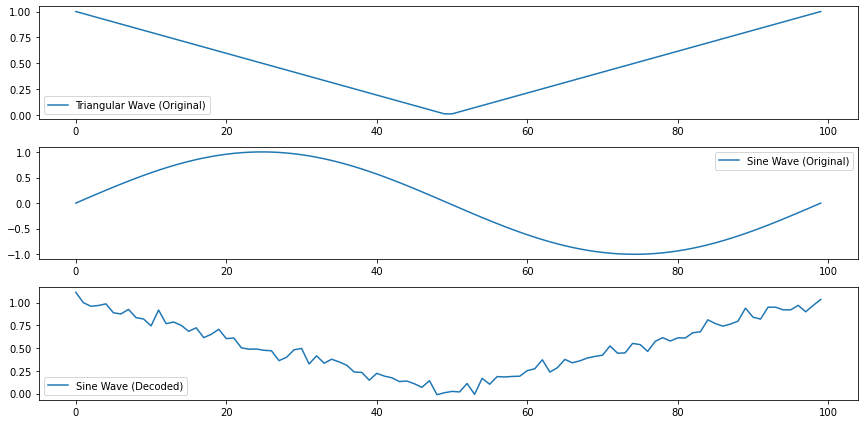

In [6]:
# Visualizando os resultados
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(triangular_wave.squeeze().numpy(), label='Triangular Wave (Original)')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(sine_wave.squeeze().numpy(), label='Sine Wave (Original)')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(decoded_sine_wave.squeeze().detach().numpy(), label='Sine Wave (Decoded)')
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
square_wave = np.sign(np.sin(np.linspace(0, 4 * np.pi, data_size)))

In [8]:
square_wave = torch.Tensor(square_wave).view(1, -1)

In [9]:
# Utilizando o Autoencoder para conformar uma senoide
encoded_square_wave = model.encoder(square_wave)
decoded_square_wave = model.decoder(encoded_square_wave)

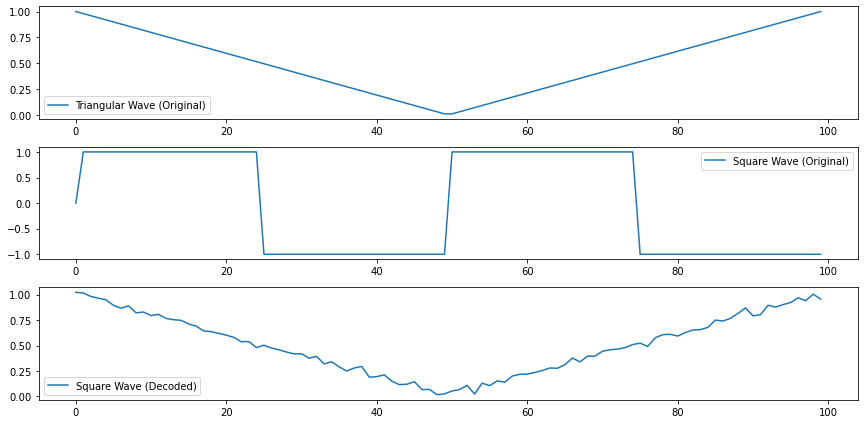

In [10]:
# Visualizando os resultados
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(triangular_wave.squeeze().numpy(), label='Triangular Wave (Original)')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(square_wave.squeeze().numpy(), label='Square Wave (Original)')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(decoded_square_wave.squeeze().detach().numpy(), label='Square Wave (Decoded)')
plt.legend()

plt.tight_layout()
plt.show()